In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
from scipy.io import loadmat
from scipy.optimize import curve_fit
import os

%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

In [16]:
dat = loadmat('data_final/dataset_Mar10_2026.mat')

locals().update(dat) #Populates all variables: ek, chi, rac, mc, omc

ek = ek.flatten()
chi = chi.flatten()

chi = chi[:-1]
rac = rac[:,:-1]
mc  = mc[:,:-1]
omc = omc[:,:-1]

dat2 = loadmat('data_final/chi0.35_data_Mar17_2026.mat') # Dataset for chi=0.35, computed till Ek=1e-9

Ek_chi35  = dat2['ek'].flatten()
rac_chi35 = dat2['rac'].flatten()
mc_chi35  = dat2['mc'].flatten()
omc_chi35 = dat2['omc'].flatten()

ek2d, chi2d = np.meshgrid(ek,chi,indexing='ij') # 2d grid of ek and chi to make matrix multiplications easier

def slice_data(chiUser=0.50):
    idx = np.argmin(np.abs(chi - chiUser))
    raSlice = rac[:,idx]
    mSlice = mc[:,idx]
    omSlice = omc[:,idx]

    return raSlice, mSlice, omSlice

In [17]:
# Defining some generic useful stuff

major_ticks = np.arange(0.,1.1,0.2)
minor_ticks = np.arange(0.05,0.96,0.03)

sizeAndFonts = 'notebook'
plotStyle = 'light'

if sizeAndFonts == 'notebook':
    tksz = 15
    axfontsize=20
    lgfontsize=13
    figW = 5.5
    figH = 4.5
    figsize = (figW,figH)
    figsizeSubplots = (13.5,4.5)
    figsizeE = (8,4.5)
    markerSize1 = 5
    markerSize2 = 10
elif sizeAndFonts == 'paper':
    tksz = 40
    axfontsize=50
    lgfontsize=30
    figW = 11
    figH = 9
    figsize = (figW,figH)
    figsizeSubplots = (27,9)
    figsizeE = (16,9)
    markerSize1 = 10
    markerSize2 = 20


gridAlpha = 0.8

Pr = 1.

cmap = cm.plasma_r

if plotStyle == 'dark':
    plt.style.use("dark_background")
    plt.rcParams.update({
        "axes.facecolor"   : "#1b1b1b",
        "figure.facecolor" : "#1b1b1b",
        "figure.edgecolor" : "#1b1b1b",
        "savefig.facecolor": "#1b1b1b",
        "savefig.edgecolor": "#1b1b1b"})

# Comparison with Dormy et al., 2004

For $\chi = 0.35$, we use values directly from Dormy et al., 2004. For the rest, we obtain the values by a least squares fit for $E \leq 10^{-5}$

### $Ra_c$

In [18]:
# Creating a class so we can pass the chi value to curve_fit

class fitClass:

    def __init__(self):
        pass


    def get_dormy_fit(self,ek_chi,Rc,R1,R_tilde):

        facRa = (1-self.chiComp)**4/self.chiComp
        facEk = 0.5 * (1-self.chiComp)**2

        ek_dormy = ek_chi * facEk

        Rac_dormy = (Rc + ek_dormy**(2./9.) * R1 + ek_dormy**(1./6.) * R_tilde) * facEk**(-4./3.)
        Rac_dormy *= facRa

        return Rac_dormy



lw = 2

chi = 0.35
----------
Rc, R1, R_tilde = 0.277, 4.051, 0.500



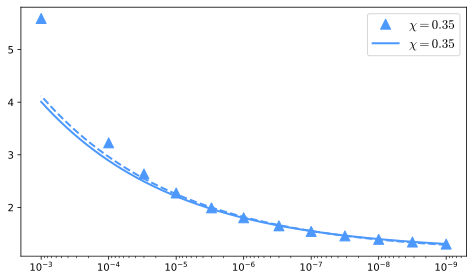

In [29]:
####################
#   chi = 0.35     #
####################

Rc = 0.285933
R1 = 4.16053
R_tilde = 0.27902

chiComp = 0.35

facRa = (1-chiComp)**4/chiComp
facEk = 0.5 * (1-chiComp)**2

ek_plot = 10**( np.linspace(-9,-3,500))
ek_dormy = ek_plot * facEk

Rac_dormy = (Rc + ek_dormy**(2./9.) * R1 + ek_dormy**(1./6.) * R_tilde) * facEk**(-4./3.)

Rac_dormy *= facRa

fig, ax = plt.subplots(figsize=figsizeE)

ax.semilogx(Ek_chi35,rac_chi35 * Ek_chi35**(4./3.),'^',color=col[0],ms=markerSize2,label=r'$\chi = 0.35$')
ax.semilogx(ek_plot,Rac_dormy,ls='-',color=col[0],lw=lw,label=r'$\chi = 0.35$')


inst0 = fitClass()
inst0.chiComp = 0.35
facEk = 0.5 * (1-inst0.chiComp)**2

mask = Ek_chi35 <= 1e-5

[Rc,R1,R_tilde], pcov = curve_fit(inst0.get_dormy_fit,Ek_chi35[mask],rac_chi35[mask] * Ek_chi35[mask]**(4./3.), p0=[0.5, 0.5, 0.5],bounds=([0,0,0.5],[np.inf,np.inf,np.inf]))

print("chi = 0.35")
print("----------")
print("Rc, R1, R_tilde = %.3f, %.3f, %.3f\n" %(Rc, R1, R_tilde))

Rac_dormy = inst0.get_dormy_fit(ek_plot,Rc,R1,R_tilde)
ax.semilogx(ek_plot,Rac_dormy,ls='--',color='#4c98fc',lw=lw)
ax.invert_xaxis()
ax.legend(fontsize=lgfontsize)
plt.show()